# Exploratory Data Analysis: AllSides / NeuS Dataset
**Project:** Model-Based Mitigation of Bias in LLM-Generated News Summaries

### Dataset Overview
* **Source:** AllSides (filtered by Lee et al., 2022 for the NeuS paper)
* **Structure:** Multi-source triplets (Left, Center, Right) mapped to a neutral summary (Roundup).
* **Total Records:** 3,066 fully usable triplets.


**Critical Questions:**
- Do Left/Center/Right articles actually show measurable bias differences?
- Are the "neutral" roundup summaries actually neutral?
- How similar are articles on the same topic across stances?
- Are train/val/test splits representative?

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import warnings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from scipy.spatial.distance import pdist, squareform
from scipy import stats
from sentibank import archive

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

# Configure paths
DATA_DIR = Path("./framing-bias-metric/data")
JSON_PATH = DATA_DIR / "naacl2022_filtered_allsides_article.json"
SPLIT_DIR = DATA_DIR / "naacl2022_lrc_roundup_random_order_probe"
OUTPUT_DIR = Path("./eda_outputs_comprehensive")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: framing-bias-metric\data
Output directory: eda_outputs_comprehensive


## 1. Data Loading and Preprocessing

In [2]:
# Load raw data
with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)
df = pd.DataFrame(raw_data)

# Flatten and extract text
def extract_text(article_data):
    if not isinstance(article_data, dict): return None
    body = article_data.get("newBody", [])
    if isinstance(body, list):
        return " ".join([str(p) for p in body])
    return str(body)

def extract_title(article_data):
    if not isinstance(article_data, dict): return None
    title = article_data.get("newsTitle", [])
    if isinstance(title, list):
        return " ".join([str(p) for p in title])
    return str(title)

for stance in ["left", "right", "center"]:
    df[f"{stance}_text"] = df[stance].apply(extract_text)
    df[f"{stance}_title"] = df[stance].apply(extract_title)
    df[f"{stance}_source"] = df[stance].apply(lambda x: x.get("newsSource") if isinstance(x, dict) else None)


df["roundup_text"] = df["roundup"].apply(
    lambda x: " ".join([str(p) for p in x]) if isinstance(x, list) else str(x)
)

# The issue is the neutral title
df["roundup_title"] = df["issue"]

print(f"Total records loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample:")
print(f"  Left title: {df['left_title'].iloc[0]}")
print(f"  Left text (first 200 chars): {df['left_text'].iloc[0][:200]}...")
print(f"  Roundup title: {df['roundup_title'].iloc[0]}")
print(f"  Roundup text (first 200 chars): {df['roundup_text'].iloc[0][:200]}...")

# Remove rows with missing critical texts
df_clean = df[
    (df['left_text'].str.len() > 0) &
    (df['right_text'].str.len() > 0) &
    (df['center_text'].str.len() > 0) &
    (df['roundup_text'].str.len() > 0)
].copy()

print(f"\nAfter cleaning: {len(df_clean)} records (removed {len(df) - len(df_clean)})")
df = df_clean


print("\nData successfully flattened with titles and text for all three stances + neutral roundup.")

Total records loaded: 3066
Columns: ['left', 'right', 'center', 'issue', 'topic', 'roundup', 'left_text', 'left_title', 'left_source', 'right_text', 'right_title', 'right_source', 'center_text', 'center_title', 'center_source', 'roundup_text', 'roundup_title']

Sample:
  Left title: North Carolina House race carries unlikely hangover from fraud scandal
  Left text (first 200 chars): CHARLOTTE, N.C. — The closely-watched special U.S. House election being held here Tuesday is taking place in the shadow of a political scandal that, according to the candidates, is having a real impac...
  Roundup title: Illegal Ballot Harvesting Prompted Re-Do of North Carolina's 9th District Election
  Roundup text (first 200 chars): Illegal ballot harvesting nullified a Republican victory in North Carolina's 9th congressional district election last year. On Tuesday, a special election is being held to determine the outcome, a pot...

After cleaning: 3064 records (removed 2)

Data successfully flattened w

## 2. Topic (domain) Distribution
Let's examine the primary focus of these multi-document triplets.

Total Unique Topics: 115
Average occurrences per topic: 26.57
Median occurrences per topic: 11.00


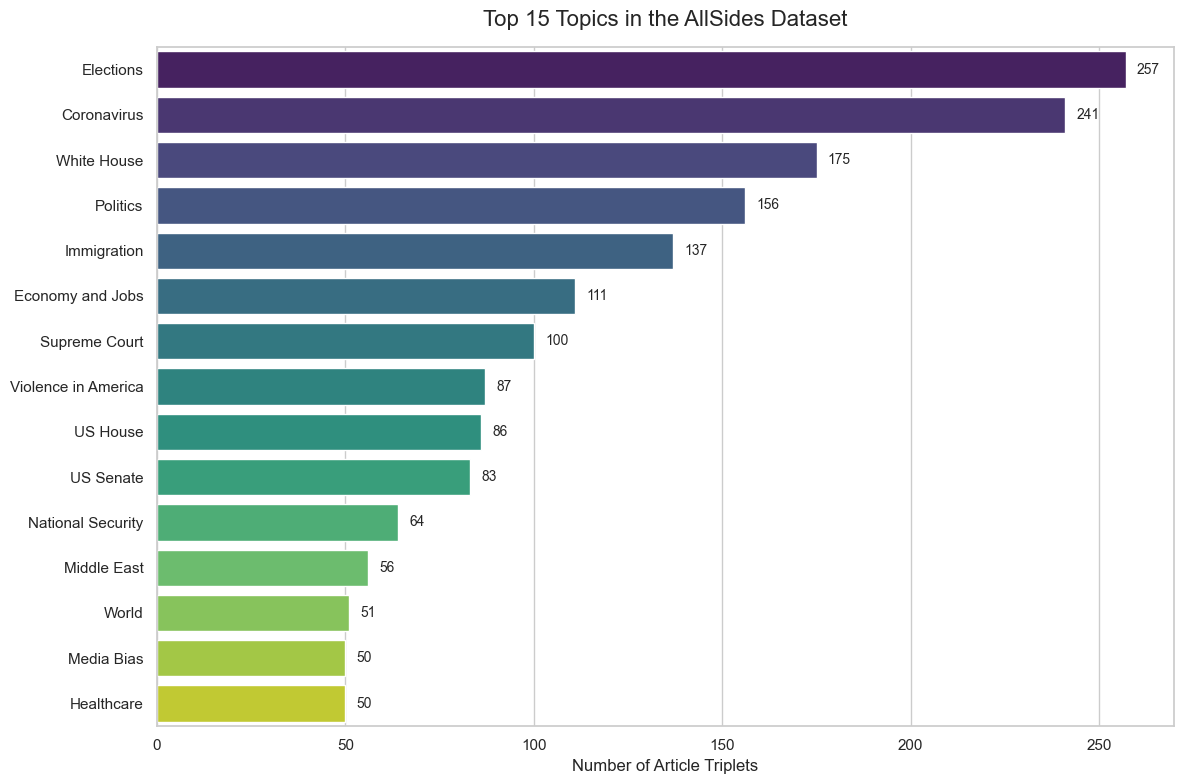

In [3]:
print('Total Unique Topics:', df['topic'].nunique())

topic_counts = df['topic'].value_counts()
avg_topics = topic_counts.mean()
median_topics = topic_counts.median()
print(f'Average occurrences per topic: {avg_topics:.2f}')
print(f'Median occurrences per topic: {median_topics:.2f}')


plt.figure(figsize=(12, 8))
top_topics = df['topic'].value_counts().head(15)

ax = sns.barplot(x=top_topics.values, y=top_topics.index, palette="viridis")
plt.title("Top 15 Topics in the AllSides Dataset", fontsize=16, pad=15)
plt.xlabel("Number of Article Triplets", fontsize=12)
plt.ylabel("")

# Add data labels
for i, v in enumerate(top_topics.values):
    ax.text(v + 3, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Context Length Analysis


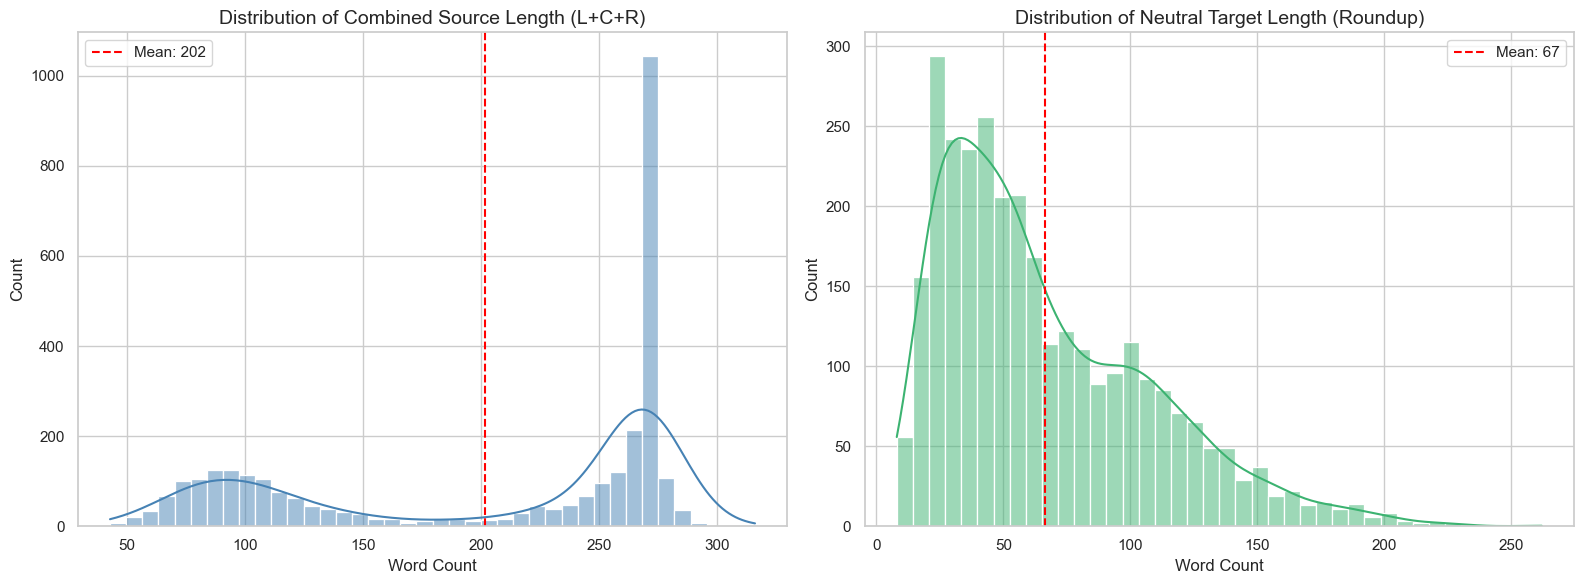

Average Context Length Required (Source + Target): ~268 words.


In [4]:
# Calculate word counts
for stance in ["left", "right", "center", "roundup"]:
    df[f"{stance}_words"] = df[f"{stance}_text"].apply(lambda x: len(str(x).split()))

df["total_source_words"] = df["left_words"] + df["right_words"] + df["center_words"]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Source Lengths
sns.histplot(data=df, x="total_source_words", bins=40, color="steelblue", kde=True, ax=axes[0])
axes[0].set_title("Distribution of Combined Source Length (L+C+R)", fontsize=14)
axes[0].set_xlabel("Word Count")
axes[0].axvline(df['total_source_words'].mean(), color='red', linestyle='--', label=f"Mean: {df['total_source_words'].mean():.0f}")
axes[0].legend()

# Target Lengths
sns.histplot(data=df, x="roundup_words", bins=40, color="mediumseagreen", kde=True, ax=axes[1])
axes[1].set_title("Distribution of Neutral Target Length (Roundup)", fontsize=14)
axes[1].set_xlabel("Word Count")
axes[1].axvline(df['roundup_words'].mean(), color='red', linestyle='--', label=f"Mean: {df['roundup_words'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average Context Length Required (Source + Target): ~{int(df['total_source_words'].mean() + df['roundup_words'].mean())} words.")


## 4. News Outlet Distribution (Source Analysis)
The following horizontal bar charts visualize the top 10 news sources for Left, Center, and Right-leaning articles.

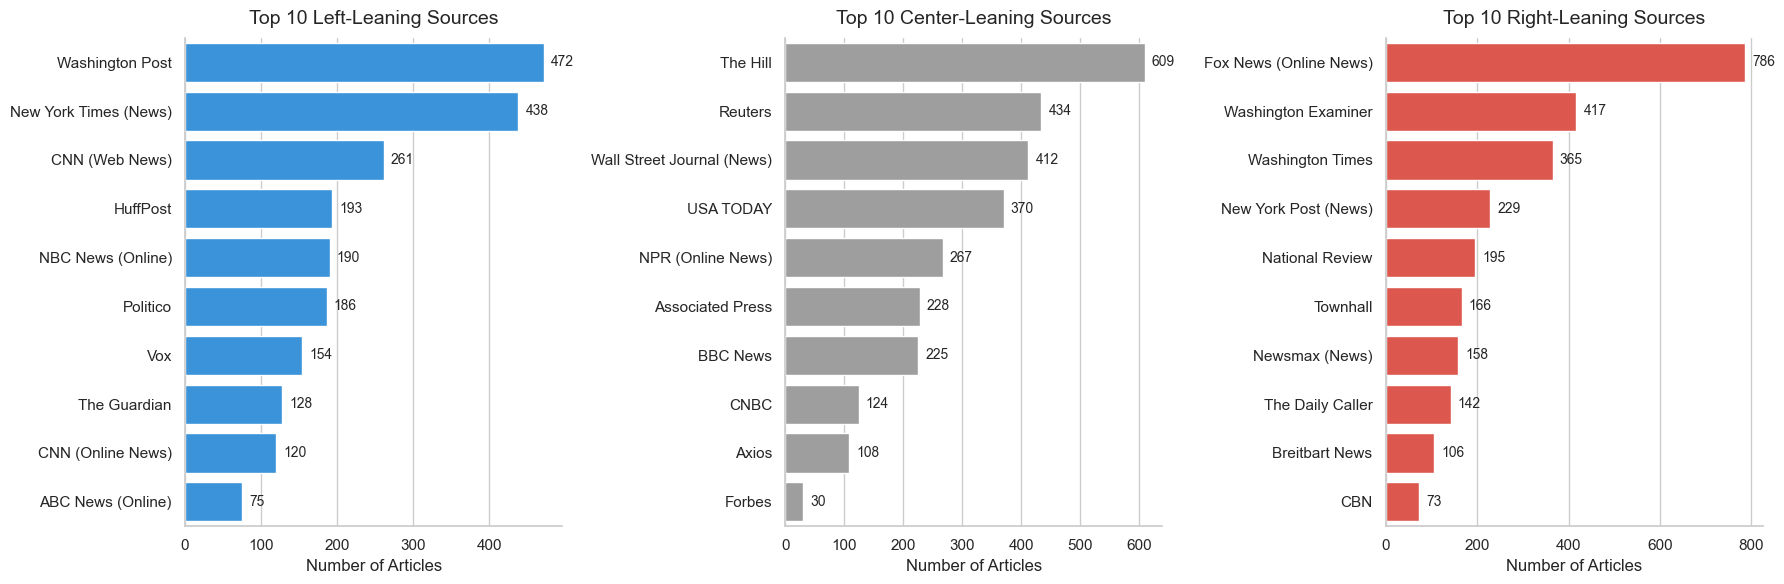

=== Source Diversity Diagnostic ===
Left: Most frequent is 'Washington Post' at 15.4% of total left articles.
Center: Most frequent is 'The Hill' at 19.9% of total center articles.
Right: Most frequent is 'Fox News (Online News)' at 25.7% of total right articles.


In [5]:
# Set up the matplotlib figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)

# Define the stances and their corresponding colors
stances = ["left", "center", "right"]
colors = ["#2196F3", "#9E9E9E", "#F44336"] # Blue, Grey, Red

for i, stance in enumerate(stances):
    # Get the top 10 most frequent sources for the current stance
    top_sources = df[f"{stance}_source"].value_counts().head(10)
    
    # Plot the horizontal bar chart
    ax = sns.barplot(x=top_sources.values, y=top_sources.index, ax=axes[i], color=colors[i])
    
    # Formatting
    axes[i].set_title(f"Top 10 {stance.capitalize()}-Leaning Sources", fontsize=14, pad=10)
    axes[i].set_xlabel("Number of Articles", fontsize=12)
    axes[i].set_ylabel("")
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    
    # Add data labels to the end of each bar
    for j, v in enumerate(top_sources.values):
        axes[i].text(v + (top_sources.max() * 0.02), j, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print a quick diagnostic summary
print("=== Source Diversity Diagnostic ===")
for stance in stances:
    top_share = (df[f"{stance}_source"].value_counts().max() / len(df)) * 100
    top_name = df[f"{stance}_source"].value_counts().index[0]
    print(f"{stance.capitalize()}: Most frequent is '{top_name}' at {top_share:.1f}% of total {stance} articles.")

## 5. VAD Arousal Metrics - Bias Validation

**Goal:** Measure emotional valence/arousal/dominance to validate that Left/Center/Right articles show different emotional framings, and that roundups are actually neutral.

We use a simple but effective approach: count emotionally-charged words (positive, negative, high-arousal) in each text.

In [6]:


# ── Load Warriner lexicon ────────────────────────────────────────────────────
print("Loading Warriner (2013) VAD lexicon...")
load = archive.load()
warriner = load.origin("NoVAD_v2013")  # check exact name — see note below
warriner = warriner.set_index("Word")[["V.Mean.Sum", "A.Mean.Sum", "D.Mean.Sum"]]
warriner.columns = ["valence", "arousal", "dominance"]
print(f"Lexicon loaded: {len(warriner)} words")
print(f"Scale: 1-9 (neutral ≈ 5, not 0)")
print(f"Sample:\n{warriner.head(3)}\n")

WARRINER_NEUTRAL = 5.0

# ── VAD computation function ─────────────────────────────────────────────────
def compute_vad_warriner(text: str) -> dict:
    """
    Compute VAD scores using Warriner et al. (2013) affective norms.
    
    Warriner scale: 1-9
    - Valence:   1=very negative, 5=neutral, 9=very positive
    - Arousal:   1=very calm, 5=moderate, 9=very exciting/intense  
    - Dominance: 1=controlled/submissive, 5=neutral, 9=dominant/in control
    
    Returns mean score across matched words.
    Returns WARRINER_NEUTRAL for each dimension if no words matched.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            "valence": WARRINER_NEUTRAL, "arousal": WARRINER_NEUTRAL, "dominance": WARRINER_NEUTRAL,
            "n_matched": 0, "n_tokens": 0, "coverage": 0.0
        }
    
    # Tokenize: lowercase, strip punctuation, keep only alpha tokens
    tokens = re.findall(r"[a-z]+", text.lower())
    
    scores = {"valence": [], "arousal": [], "dominance": []}
    
    for word in tokens:
        if word in warriner.index:
            scores["valence"].append(warriner.loc[word, "valence"])
            scores["arousal"].append(warriner.loc[word, "arousal"])
            scores["dominance"].append(warriner.loc[word, "dominance"])
    
    n_matched = len(scores["valence"])
    n_tokens  = len(tokens)
    
    return {
        "valence":   sum(scores["valence"])   / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "arousal":   sum(scores["arousal"])   / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "dominance": sum(scores["dominance"]) / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "n_matched": n_matched,
        "n_tokens":  n_tokens,
        "coverage":  n_matched / n_tokens if n_tokens > 0 else 0.0
    }

# ── Apply to all stances ─────────────────────────────────────────────────────
print("Computing Warriner VAD features...")

for stance in ["left", "center", "right", "roundup"]:
    col = "roundup_text" if stance == "roundup" else f"{stance}_text"
    print(f"  Processing {stance}...")
    
    vad_results = df[col].apply(compute_vad_warriner)
    
    df[f"{stance}_valence"]   = vad_results.apply(lambda x: x["valence"])
    df[f"{stance}_arousal"]   = vad_results.apply(lambda x: x["arousal"])
    df[f"{stance}_dominance"] = vad_results.apply(lambda x: x["dominance"])
    df[f"{stance}_vad_coverage"] = vad_results.apply(lambda x: x["coverage"])

print("VAD computation complete.\n")

# ── Sanity check ─────────────────────────────────────────────────────────────
print("SANITY CHECK — mean scores per stance (Warriner scale 1-9, neutral=5):")
print(f"{'Stance':<12} {'Valence':>10} {'Arousal':>10} {'Dominance':>10} {'Coverage':>10}")
print("-" * 55)
for stance in ["left", "center", "right", "roundup"]:
    v = df[f"{stance}_valence"].mean()
    a = df[f"{stance}_arousal"].mean()
    d = df[f"{stance}_dominance"].mean()
    c = df[f"{stance}_vad_coverage"].mean()
    print(f"{stance:<12} {v:>10.3f} {a:>10.3f} {d:>10.3f} {c:>10.1%}")



Loading Warriner (2013) VAD lexicon...
Lexicon loaded: 13915 words
Scale: 1-9 (neutral ≈ 5, not 0)
Sample:
          valence  arousal  dominance
Word                                 
aardvark     6.26     2.41       4.27
abalone      5.30     2.65       4.95
abandon      2.84     3.73       3.32

Computing Warriner VAD features...
  Processing left...
  Processing center...
  Processing right...
  Processing roundup...
VAD computation complete.

SANITY CHECK — mean scores per stance (Warriner scale 1-9, neutral=5):
Stance          Valence    Arousal  Dominance   Coverage
-------------------------------------------------------
left              5.298      4.109      5.369      31.9%
center            5.289      4.103      5.369      32.2%
right             5.315      4.103      5.377      32.5%
roundup           5.269      4.102      5.373      32.6%


### VAD Summary Statistics

In [7]:


print("\n" + "="*80)
print("VAD FEATURE SUMMARY - BIAS VALIDATION (Warriner 2013)")
print("Scale: 1-9 | Neutral = 5.0")
print("="*80)

stances     = ['left', 'center', 'right', 'roundup']
vad_metrics = ['valence', 'arousal', 'dominance', 'vad_coverage']

summary_stats = {}
for stance in stances:
    print(f"\n{stance.upper()}:")
    for metric in vad_metrics:
        col = f'{stance}_{metric}'
        if col not in df.columns:
            print(f"  {metric:15s}: MISSING — rerun compute_vad_warriner()")
            continue
        mean_val = df[col].mean()
        std_val  = df[col].std()
        summary_stats[f'{stance}_{metric}'] = (mean_val, std_val)
        # Flag if coverage is low — means few words matched the lexicon
        note = " ⚠ low coverage" if metric == "vad_coverage" and mean_val < 0.3 else ""
        print(f"  {metric:15s}: mean={mean_val:7.3f}, std={std_val:6.3f}{note}")


# =============================================================================
# VALENCE ANALYSIS
# =============================================================================
print(f"\n" + "="*80)
print("VALENCE ANALYSIS (1=negative, 5=neutral, 9=positive)")
print("="*80)

left_valence    = df['left_valence'].dropna()
right_valence   = df['right_valence'].dropna()
center_valence  = df['center_valence'].dropna()
roundup_valence = df['roundup_valence'].dropna()

print(f"\nMean Valence per Stance:")
print(f"  Left:    {left_valence.mean():.3f}")
print(f"  Center:  {center_valence.mean():.3f}")
print(f"  Right:   {right_valence.mean():.3f}")
print(f"  Roundup: {roundup_valence.mean():.3f}")
print(f"  (Neutral baseline = 5.0)")

# One-way ANOVA: do Left/Center/Right differ?
f_stat, p_val = stats.f_oneway(left_valence, center_valence, right_valence)
print(f"\n  ANOVA (Left vs Center vs Right): F={f_stat:.4f}, p={p_val:.2e}")
if p_val < 0.05:
    print(f"  ✓ Valence differs significantly across stances — bias signal confirmed")
else:
    print(f"  ✗ Valence similar across stances — weak bias signal")

# T-tests: roundup vs each stance
t_lr, p_lr = stats.ttest_ind(left_valence, right_valence)
t_rl, p_rl = stats.ttest_ind(roundup_valence, left_valence)
t_rr, p_rr = stats.ttest_ind(roundup_valence, right_valence)
t_rc, p_rc = stats.ttest_ind(roundup_valence, center_valence)

print(f"\n  Left vs Right t-test:      t={t_lr:.4f}, p={p_lr:.2e}", "✓" if p_lr < 0.05 else "✗")
print(f"  Roundup vs Left t-test:    t={t_rl:.4f}, p={p_rl:.2e}", "✓" if p_rl < 0.05 else "✗")
print(f"  Roundup vs Right t-test:   t={t_rr:.4f}, p={p_rr:.2e}", "✓" if p_rr < 0.05 else "✗")
print(f"  Roundup vs Center t-test:  t={t_rc:.4f}, p={p_rc:.2e}", "✓" if p_rc < 0.05 else "✗")

# Neutrality check: is roundup closer to 5.0 than left/right?
roundup_deviation = abs(roundup_valence.mean() - 5.0)
left_deviation    = abs(left_valence.mean()    - 5.0)
right_deviation   = abs(right_valence.mean()   - 5.0)
print(f"\n  Distance from neutral (5.0):")
print(f"    Left:    {left_deviation:.3f}")
print(f"    Right:   {right_deviation:.3f}")
print(f"    Roundup: {roundup_deviation:.3f}")
if roundup_deviation < left_deviation and roundup_deviation < right_deviation:
    print(f"  ✓ Roundup is closer to neutral than both Left and Right")
else:
    print(f"  ⚠ Roundup is NOT closer to neutral — investigate roundup quality")


# =============================================================================
# AROUSAL ANALYSIS
# =============================================================================
print(f"\n" + "="*80)
print("AROUSAL ANALYSIS (1=calm, 5=moderate, 9=intense)")
print("="*80)

left_arousal    = df['left_arousal'].dropna()
right_arousal   = df['right_arousal'].dropna()
center_arousal  = df['center_arousal'].dropna()
roundup_arousal = df['roundup_arousal'].dropna()

print(f"\nMean Arousal per Stance:")
print(f"  Left:    {left_arousal.mean():.3f}")
print(f"  Center:  {center_arousal.mean():.3f}")
print(f"  Right:   {right_arousal.mean():.3f}")
print(f"  Roundup: {roundup_arousal.mean():.3f}")

f_stat_a, p_val_a = stats.f_oneway(left_arousal, center_arousal, right_arousal)
print(f"\n  ANOVA (Left vs Center vs Right): F={f_stat_a:.4f}, p={p_val_a:.2e}")
if p_val_a < 0.05:
    print(f"  ✓ Arousal differs significantly across stances")
else:
    print(f"  ✗ Arousal similar across stances")

t_al, p_al = stats.ttest_ind(roundup_arousal, left_arousal)
t_ar, p_ar = stats.ttest_ind(roundup_arousal, right_arousal)
t_ac, p_ac = stats.ttest_ind(roundup_arousal, center_arousal)

print(f"\n  Roundup vs Left t-test:    t={t_al:.4f}, p={p_al:.2e}", "✓" if p_al < 0.05 else "✗")
print(f"  Roundup vs Right t-test:   t={t_ar:.4f}, p={p_ar:.2e}", "✓" if p_ar < 0.05 else "✗")
print(f"  Roundup vs Center t-test:  t={t_ac:.4f}, p={p_ac:.2e}", "✓" if p_ac < 0.05 else "✗")

roundup_arousal_dev = abs(roundup_arousal.mean() - 5.0)
left_arousal_dev    = abs(left_arousal.mean()    - 5.0)
right_arousal_dev   = abs(right_arousal.mean()   - 5.0)
print(f"\n  Distance from neutral arousal (5.0):")
print(f"    Left:    {left_arousal_dev:.3f}")
print(f"    Right:   {right_arousal_dev:.3f}")
print(f"    Roundup: {roundup_arousal_dev:.3f}")


# =============================================================================
# DOMINANCE ANALYSIS
# =============================================================================
print(f"\n" + "="*80)
print("DOMINANCE ANALYSIS (1=submissive/powerless, 5=neutral, 9=dominant/in control)")
print("="*80)

left_dominance    = df['left_dominance'].dropna()
right_dominance   = df['right_dominance'].dropna()
center_dominance  = df['center_dominance'].dropna()
roundup_dominance = df['roundup_dominance'].dropna()

print(f"\nMean Dominance per Stance:")
print(f"  Left:    {left_dominance.mean():.3f}")
print(f"  Center:  {center_dominance.mean():.3f}")
print(f"  Right:   {right_dominance.mean():.3f}")
print(f"  Roundup: {roundup_dominance.mean():.3f}")

f_stat_d, p_val_d = stats.f_oneway(left_dominance, center_dominance, right_dominance)
print(f"\n  ANOVA (Left vs Center vs Right): F={f_stat_d:.4f}, p={p_val_d:.2e}")
if p_val_d < 0.05:
    print(f"  ✓ Dominance differs significantly across stances")
else:
    print(f"  ✗ Dominance similar across stances")

t_dl, p_dl = stats.ttest_ind(roundup_dominance, left_dominance)
t_dr, p_dr = stats.ttest_ind(roundup_dominance, right_dominance)
t_dc, p_dc = stats.ttest_ind(roundup_dominance, center_dominance)

print(f"\n  Roundup vs Left t-test:    t={t_dl:.4f}, p={p_dl:.2e}", "✓" if p_dl < 0.05 else "✗")
print(f"  Roundup vs Right t-test:   t={t_dr:.4f}, p={p_dr:.2e}", "✓" if p_dr < 0.05 else "✗")
print(f"  Roundup vs Center t-test:  t={t_dc:.4f}, p={p_dc:.2e}", "✓" if p_dc < 0.05 else "✗")


# =============================================================================
# OVERALL BIAS SIGNAL SUMMARY
# =============================================================================
print(f"\n" + "="*80)
print("OVERALL BIAS SIGNAL SUMMARY")
print("="*80)

signals = {
    "Valence":   p_val   < 0.05,
    "Arousal":   p_val_a < 0.05,
    "Dominance": p_val_d < 0.05,
}

for dim, significant in signals.items():
    status = "✓ SIGNIFICANT" if significant else "✗ NOT SIGNIFICANT"
    print(f"  {dim:<12}: {status}")

n_significant = sum(signals.values())
print(f"\n  {n_significant}/3 VAD dimensions show significant stance differences")

if n_significant >= 2:
    print(f"  ✓ Dataset contains measurable bias signal — fine-tuning is well-motivated")
elif n_significant == 1:
    print(f"  ~ WEAK signal — bias may be subtle in this dataset")
else:
    print(f"  ✗ No significant bias signal — reconsider dataset or metrics")

# Roundup neutrality verdict
roundup_neutral_count = sum([
    roundup_deviation    < min(left_deviation, right_deviation),
    roundup_arousal_dev  < min(left_arousal_dev, right_arousal_dev),
    abs(roundup_dominance.mean() - 5.0) < min(
        abs(left_dominance.mean() - 5.0),
        abs(right_dominance.mean() - 5.0)
    )
])
print(f"\n  Roundup neutrality: closer to neutral than L/R on {roundup_neutral_count}/3 dimensions")
if roundup_neutral_count >= 2:
    print(f"  ✓ Roundups appear to be valid neutral targets for fine-tuning")
else:
    print(f"  ⚠ Roundups may not be reliably neutral — document as limitation")


VAD FEATURE SUMMARY - BIAS VALIDATION (Warriner 2013)
Scale: 1-9 | Neutral = 5.0

LEFT:
  valence        : mean=  5.298, std= 0.391
  arousal        : mean=  4.109, std= 0.282
  dominance      : mean=  5.369, std= 0.298
  vad_coverage   : mean=  0.319, std= 0.070

CENTER:
  valence        : mean=  5.289, std= 0.384
  arousal        : mean=  4.103, std= 0.265
  dominance      : mean=  5.369, std= 0.287
  vad_coverage   : mean=  0.322, std= 0.067

RIGHT:
  valence        : mean=  5.315, std= 0.396
  arousal        : mean=  4.103, std= 0.260
  dominance      : mean=  5.377, std= 0.290
  vad_coverage   : mean=  0.325, std= 0.067

ROUNDUP:
  valence        : mean=  5.269, std= 0.395
  arousal        : mean=  4.102, std= 0.273
  dominance      : mean=  5.373, std= 0.297
  vad_coverage   : mean=  0.326, std= 0.071

VALENCE ANALYSIS (1=negative, 5=neutral, 9=positive)

Mean Valence per Stance:
  Left:    5.298
  Center:  5.289
  Right:   5.315
  Roundup: 5.269
  (Neutral baseline = 5.0)

  AN

### VAD Distribution by Stance

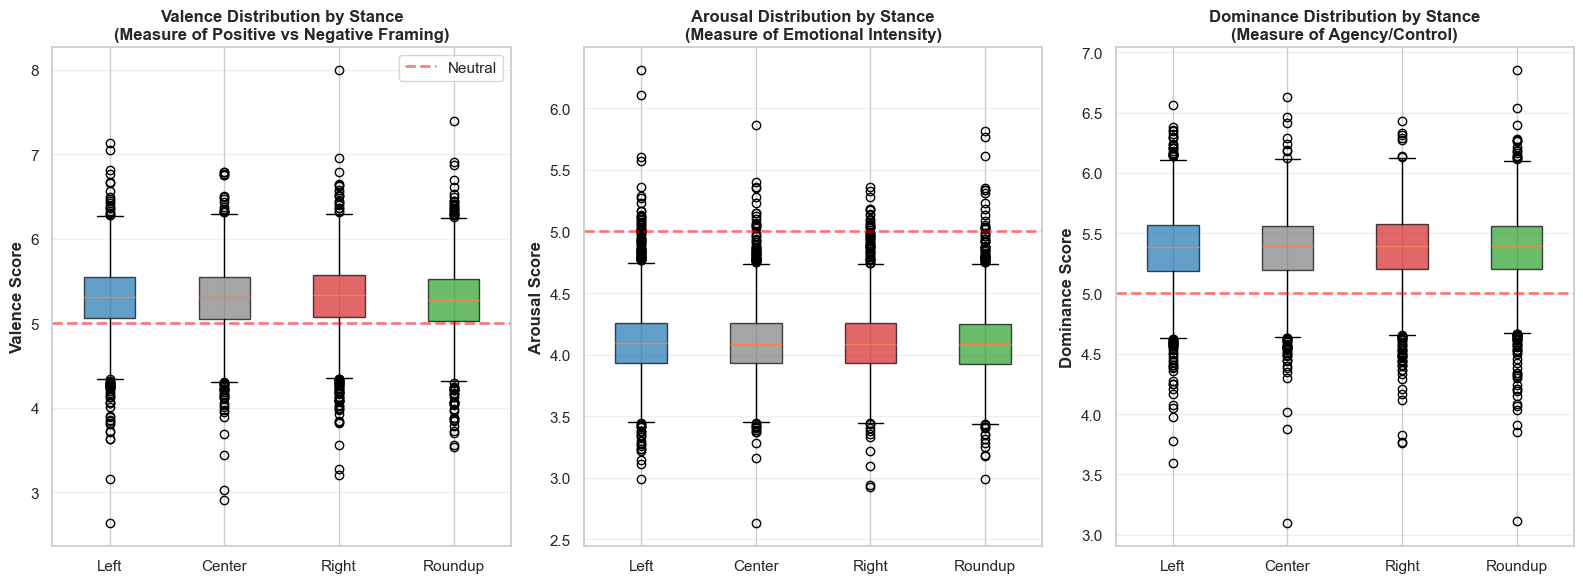

VAD box plots saved.


In [8]:
# Create box plots for Valence and Arousal
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# # Prepare data for box plot
# valence_data = [
#     df['left_valence'],
#     df['center_valence'],
#     df['right_valence'],
#     df['roundup_valence']
# ]
# arousal_data = [
#     df['left_arousal'],
#     df['center_arousal'],
#     df['right_arousal'],
#     df['roundup_arousal']
# ]


# dominance_data = [
#     df['left_dominance'],
#     df['center_dominance'],
#     df['right_dominance'],
#     df['roundup_dominance']
# ]

# Prepare data — explicitly drop NaN values
valence_data = [
    df['left_valence'].dropna().values,
    df['center_valence'].dropna().values,
    df['right_valence'].dropna().values,
    df['roundup_valence'].dropna().values,
]
arousal_data = [
    df['left_arousal'].dropna().values,
    df['center_arousal'].dropna().values,
    df['right_arousal'].dropna().values,
    df['roundup_arousal'].dropna().values,
]
dominance_data = [
    df['left_dominance'].dropna().values,
    df['center_dominance'].dropna().values,
    df['right_dominance'].dropna().values,
    df['roundup_dominance'].dropna().values,
]

   
labels = ['Left', 'Center', 'Right', 'Roundup']
colors_list = ['#1f77b4', '#7f7f7f', '#d62728', '#2ca02c']

# Valence boxplot
bp1 = axes[0].boxplot(valence_data, labels=labels, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Valence Score', fontsize=12, fontweight='bold')
axes[0].set_title('Valence Distribution by Stance\n(Measure of Positive vs Negative Framing)', 
                  fontsize=12, fontweight='bold')
axes[0].axhline(y=5, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Neutral')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].legend()

# Arousal boxplot
bp2 = axes[1].boxplot(arousal_data, labels=labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Arousal Score', fontsize=12, fontweight='bold')
axes[1].set_title('Arousal Distribution by Stance\n(Measure of Emotional Intensity)', 
                  fontsize=12, fontweight='bold')
axes[1].axhline(y=5, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Neutral')
axes[1].grid(True, alpha=0.3, axis='y')



# Dominance boxplot
bp3 = axes[2].boxplot(dominance_data, labels=labels, patch_artist=True)
for patch, color in zip(bp3['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel('Dominance Score', fontsize=12, fontweight='bold')
axes[2].set_title('Dominance Distribution by Stance\n(Measure of Agency/Control)', 
                  fontsize=12, fontweight='bold')
axes[2].axhline(y=5, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Neutral')
axes[2].grid(True, alpha=0.3, axis='y')

axes[2].set_title('Dominance Distribution by Stance\n(Measure of Agency/Control)', 
                  fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vad_boxplots_by_stance.png', dpi=300, bbox_inches='tight')
plt.show()

print("VAD box plots saved.")

## 6. Similarity Analysis - Article Overlap by Topic

**Goal:** Measure how similar Left/Center/Right articles are on the same topic. High similarity → model learns to recognize similar content. Low similarity → model learns stance distribution.

In [9]:
# Compute TF-IDF vectorizer for similarity analysis
print("Computing article similarity (TF-IDF)...")

# For each sample, we'll compute similarity between Left-Center, Left-Right, Center-Right
def compute_similarities(row):
    """
    For a single row (one topic), compute pairwise TF-IDF similarity
    between Left, Center, Right articles.
    """
    texts = [
        row['left_text'],
        row['center_text'],
        row['right_text']
    ]
    
    # Vectorize
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
    try:
        tfidf_matrix = vectorizer.fit_transform(texts)
        # Compute pairwise cosine similarity
        similarities = cosine_similarity(tfidf_matrix)
        
        return {
            'left_center_sim': similarities[0, 1],
            'left_right_sim': similarities[0, 2],
            'center_right_sim': similarities[1, 2],
            'mean_sim': (similarities[0, 1] + similarities[0, 2] + similarities[1, 2]) / 3
        }
    except:
        return {'left_center_sim': 0, 'left_right_sim': 0, 'center_right_sim': 0, 'mean_sim': 0}

# Sample 1000 random rows for efficiency (similarity computation is expensive)
sample_size = min(4000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

similarities = df_sample.apply(compute_similarities, axis=1, result_type='expand')
print(f"Computed similarities for {len(similarities)} samples.")

# Display statistics
print(f"\nPairwise Similarity Statistics:")
print(f"  Left-Center:  mean={similarities['left_center_sim'].mean():.3f}, std={similarities['left_center_sim'].std():.3f}")
print(f"  Left-Right:   mean={similarities['left_right_sim'].mean():.3f}, std={similarities['left_right_sim'].std():.3f}")
print(f"  Center-Right: mean={similarities['center_right_sim'].mean():.3f}, std={similarities['center_right_sim'].std():.3f}")
print(f"  Overall Mean: mean={similarities['mean_sim'].mean():.3f}, std={similarities['mean_sim'].std():.3f}")

# Interpretation
mean_sim = similarities['mean_sim'].mean()
print(f"\nInterpretation:")
if mean_sim > 0.5:
    print(f"  ✓ Articles on same topic are VERY SIMILAR ({mean_sim:.2%})")
    print(f"    → Model can learn to neutralize framing without major content changes")
elif mean_sim > 0.3:
    print(f"  ~ Articles on same topic are MODERATELY SIMILAR ({mean_sim:.2%})")
    print(f"    → Model can learn framing differences but will need to handle varying content")
else:
    print(f"  ✗ Articles on same topic are VERY DIFFERENT ({mean_sim:.2%})")
    print(f"    → Model may learn to generate roundup distribution rather than neutralize bias")

Computing article similarity (TF-IDF)...
Computed similarities for 3064 samples.

Pairwise Similarity Statistics:
  Left-Center:  mean=0.198, std=0.125
  Left-Right:   mean=0.190, std=0.124
  Center-Right: mean=0.208, std=0.120
  Overall Mean: mean=0.199, std=0.099

Interpretation:
  ✗ Articles on same topic are VERY DIFFERENT (19.88%)
    → Model may learn to generate roundup distribution rather than neutralize bias


### Similarity Distribution Visualization

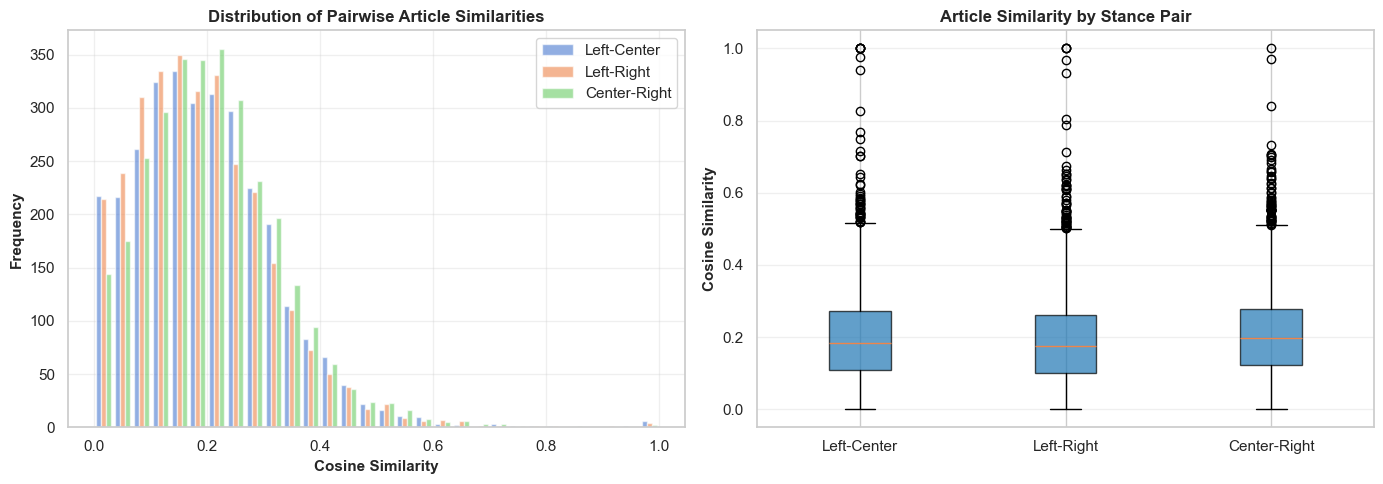

Similarity plots saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of pairwise similarities
axes[0].hist([similarities['left_center_sim'],
              similarities['left_right_sim'],
              similarities['center_right_sim']],
            bins=30, alpha=0.6, label=['Left-Center', 'Left-Right', 'Center-Right'])
axes[0].set_xlabel('Cosine Similarity', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Pairwise Article Similarities', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
sim_data = [
    similarities['left_center_sim'],
    similarities['left_right_sim'],
    similarities['center_right_sim']
]
bp = axes[1].boxplot(sim_data, labels=['Left-Center', 'Left-Right', 'Center-Right'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
axes[1].set_ylabel('Cosine Similarity', fontsize=11, fontweight='bold')
axes[1].set_title('Article Similarity by Stance Pair', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'article_similarity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Similarity plots saved.")

## 7. Fine-Grained Length Analysis by Topic

In [11]:
# Compute lengths
df['left_len'] = df['left_text'].str.len()
df['right_len'] = df['right_text'].str.len()
df['center_len'] = df['center_text'].str.len()
df['roundup_len'] = df['roundup_text'].str.len()

print("\nLength Statistics (characters):")
print(f"\n  LEFT articles:")
print(f"    Mean: {df['left_len'].mean():.0f}, Median: {df['left_len'].median():.0f}, Std: {df['left_len'].std():.0f}")
print(f"    Min: {df['left_len'].min():.0f}, Max: {df['left_len'].max():.0f}")

print(f"\n  CENTER articles:")
print(f"    Mean: {df['center_len'].mean():.0f}, Median: {df['center_len'].median():.0f}, Std: {df['center_len'].std():.0f}")
print(f"    Min: {df['center_len'].min():.0f}, Max: {df['center_len'].max():.0f}")

print(f"\n  RIGHT articles:")
print(f"    Mean: {df['right_len'].mean():.0f}, Median: {df['right_len'].median():.0f}, Std: {df['right_len'].std():.0f}")
print(f"    Min: {df['right_len'].min():.0f}, Max: {df['right_len'].max():.0f}")

print(f"\n  ROUNDUP (target):")
print(f"    Mean: {df['roundup_len'].mean():.0f}, Median: {df['roundup_len'].median():.0f}, Std: {df['roundup_len'].std():.0f}")
print(f"    Min: {df['roundup_len'].min():.0f}, Max: {df['roundup_len'].max():.0f}")

# Compression ratio
print(f"\nCompression Ratios (Roundup / Article):")
df['compression_left'] = df['roundup_len'] / (df['left_len'] + 1)
df['compression_right'] = df['roundup_len'] / (df['right_len'] + 1)
df['compression_center'] = df['roundup_len'] / (df['center_len'] + 1)
df['mean_compression'] = (df['compression_left'] + df['compression_right'] + df['compression_center']) / 3

print(f"  vs Left:   mean={df['compression_left'].mean():.2f}, std={df['compression_left'].std():.2f}")
print(f"  vs Center: mean={df['compression_center'].mean():.2f}, std={df['compression_center'].std():.2f}")
print(f"  vs Right:  mean={df['compression_right'].mean():.2f}, std={df['compression_right'].std():.2f}")


Length Statistics (characters):

  LEFT articles:
    Mean: 424, Median: 527, Std: 180
    Min: 14, Max: 692

  CENTER articles:
    Mean: 418, Median: 525, Std: 180
    Min: 46, Max: 821

  RIGHT articles:
    Mean: 423, Median: 523, Std: 175
    Min: 10, Max: 724

  ROUNDUP (target):
    Mean: 424, Median: 351, Std: 266
    Min: 49, Max: 1643

Compression Ratios (Roundup / Article):
  vs Left:   mean=1.19, std=1.07
  vs Center: mean=1.10, std=0.62
  vs Right:  mean=1.12, std=1.00


### Length Distribution Visualization

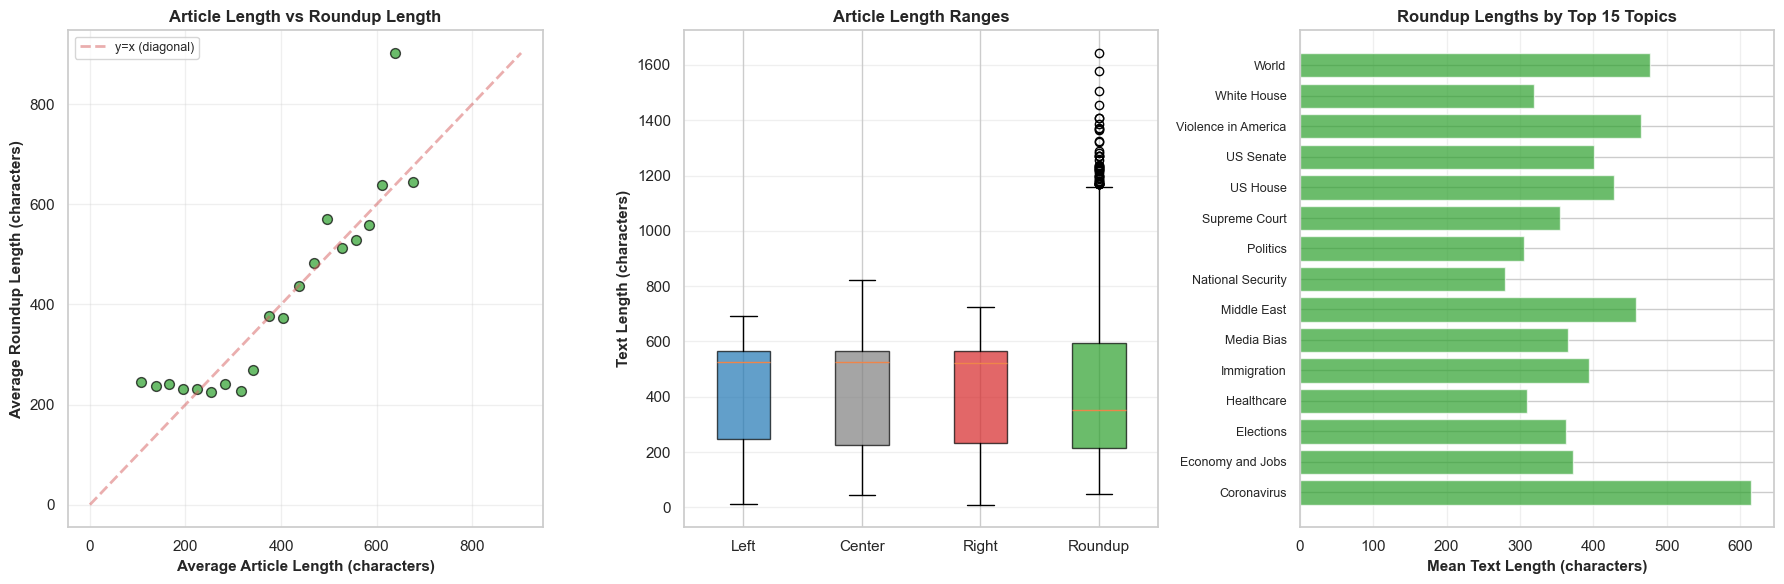

Length analysis plots saved.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scatter
df['avg_article_len'] = (df['left_len'] + df['center_len'] + df['right_len']) / 3
n_bins = 20
df['len_bin'] = pd.cut(df['avg_article_len'], bins=n_bins)
bin_stats = df.groupby('len_bin').agg({
    'avg_article_len': 'mean',
    'roundup_len': 'mean'
}).dropna()

axes[0].scatter(bin_stats['avg_article_len'], bin_stats['roundup_len'], 
                alpha=0.7, s=50, c='#2ca02c', edgecolors='black', linewidth=1)

max_len = max(bin_stats['avg_article_len'].max(), bin_stats['roundup_len'].max())
axes[0].plot([0, max_len], [0, max_len], 'r--', alpha=0.5, linewidth=2, label='y=x (diagonal)')

axes[0].set_xlabel('Average Article Length (characters)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Roundup Length (characters)', fontsize=11, fontweight='bold')
axes[0].set_title('Article Length vs Roundup Length', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Box plot
length_data = [df['left_len'], df['center_len'], df['right_len'], df['roundup_len']]
bp = axes[1].boxplot(length_data, labels=['Left', 'Center', 'Right', 'Roundup'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#7f7f7f', '#d62728', '#2ca02c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Text Length (characters)', fontsize=11, fontweight='bold')
axes[1].set_title('Article Length Ranges', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')


# Mean text length by topic (top 15 topics)
top_topics = df['topic'].value_counts().head(15).index
df_top = df[df['topic'].isin(top_topics)]
byopic_lengths = df_top.groupby('topic')[['left_len', 'center_len', 'right_len', 'roundup_len']].mean()

axes[2].barh(range(len(byopic_lengths)), byopic_lengths['roundup_len'], alpha=0.7, color='#2ca02c', label='Roundup')
axes[2].set_yticks(range(len(byopic_lengths)))
axes[2].set_yticklabels([t[:20] for t in byopic_lengths.index], fontsize=9)
axes[2].set_xlabel('Mean Text Length (characters)', fontsize=11, fontweight='bold')
axes[2].set_title('Roundup Lengths by Top 15 Topics', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Length analysis plots saved.")

## 8. Train/Val/Test Split Analysis

**Goal:** Verify that splits are properly separated and representative across topics.

**Approach:** Match dataframe rows to splits using title-based matching (NeuS split files have different text format)

In [13]:
# Load the official train/val/test splits
print("Loading train/val/test splits from NeuS...")

splits = {}
for split_name in ['train', 'val', 'test']:
    source_file = SPLIT_DIR / f"{split_name}.source"
    target_file = SPLIT_DIR / f"{split_name}.target"
    
    if source_file.exists() and target_file.exists():
        with open(source_file, 'r', encoding='utf-8') as f:
            sources = f.read().strip().split('\n')
        with open(target_file, 'r', encoding='utf-8') as f:
            targets = f.read().strip().split('\n')
        

        titles = []
        for target in targets:
            match = re.search(r'TITLE=> ([^.]+)', target)
            if match:
                title = match.group(1).strip()
                titles.append(title)
            else:
                titles.append("")
        
        splits[split_name] = {
            'sources': sources,
            'targets': targets,
            'titles': titles,
            'count': len(sources)
        }
        print(f"  {split_name:6s}: {len(sources):4d} examples")

total_split = sum(s['count'] for s in splits.values())
print(f"  Total:  {total_split} examples")
print(f"\nNote: Original dataset has {len(df)} examples.")
if total_split == len(df):
    print(f"✓ Splits account for all data.")
else:
    print(f"⚠ Note: {len(df)} in dataframe vs {total_split} in splits (formatting differences)")

Loading train/val/test splits from NeuS...
  train : 2452 examples
  val   :  307 examples
  test  :  307 examples
  Total:  3066 examples

Note: Original dataset has 3064 examples.
⚠ Note: 3064 in dataframe vs 3066 in splits (formatting differences)


In [14]:
# Extract roundup titles from dataframe for matching
def extract_roundup_title(roundup):
    """Extract title from roundup nested structure."""
    if isinstance(roundup, str):
        return roundup[:100]
    elif isinstance(roundup, list):
        for item in roundup:
            if isinstance(item, str):
                return item[:100]
            elif isinstance(item, dict):
                for k in ["newsTitle", "title", "text"]:
                    if k in item:
                        t = item[k]
                        if isinstance(t, list):
                            return "".join(t)[:100]
                        else:
                            return str(t)[:100]
    return ""

df['roundup_title_key'] = df['roundup'].apply(extract_roundup_title)

# Create mapping from split targets (using normalized titles)
print("Creating title-based split mapping...")

title_to_split = {}
for split_name in ['train', 'val', 'test']:
    for idx, title in enumerate(splits[split_name]['titles']):
        if title:
            # Normalize: lowercase, strip, remove extra spaces
            normalized = " ".join(title.lower().split())
            title_to_split[normalized] = split_name

print(f"Created mapping for {len(title_to_split)} split titles")

# Assign splits to dataframe
def get_split(title_key):
    """Find split for a given title."""
    if not title_key:
        return 'unknown'
    normalized = " ".join(title_key.lower().split())
    return title_to_split.get(normalized, 'unknown')

df['split'] = df['roundup_title_key'].apply(get_split)

print("\nSplit Assignment Summary:")
split_counts = df['split'].value_counts()
for split_name in ['train', 'val', 'test']:
    count = split_counts.get(split_name, 0)
    pct = count / len(df) * 100
    print(f"  {split_name:6s}: {count:4d} ({pct:5.1f}%)")

unknown = split_counts.get('unknown', 0)
if unknown > 0:
    print(f"  unknown: {unknown:4d} (could not match)")
    print(f"\n  Note: Attempting fallback to index-based assignment...")

# FALLBACK: If title matching fails, use index-based assignment
if unknown > len(df) * 0.1:
    print(f"\n⚠ Warning: {unknown/len(df)*100:.1f}% unmatched. Using fallback index-based assignment...")
    
    df['split'] = 'unknown'
    idx = 0
    for split_name in ['train', 'val', 'test']:
        split_size = splits[split_name]['count']
        df.loc[idx:idx+split_size-1, 'split'] = split_name
        idx += split_size
    
    print("Fallback assignment complete.")
    split_counts = df['split'].value_counts()
    for split_name in ['train', 'val', 'test']:
        count = split_counts.get(split_name, 0)
        pct = count / len(df) * 100
        print(f"  {split_name:6s}: {count:4d} ({pct:5.1f}%)")

# Topic distribution across splits
print(f"\nTopic Coverage Across Splits:")
for split_name in ['train', 'val', 'test']:
    split_df = df[df['split'] == split_name]
    n_topics = split_df['topic'].nunique()
    print(f"  {split_name}: {n_topics} unique topics")

# Check for topic leakage (same topic in multiple splits)
print(f"\nTopic Leakage Check:")
topic_splits = df[df['split'] != 'unknown'].groupby('topic')['split'].nunique()
topic_leakage = (topic_splits > 1).sum()
if topic_leakage > 0:
    print(f"  ⚠ WARNING: {topic_leakage} topics appear in multiple splits!")
    print(f"    This suggests data was shuffled before splitting (acceptable).")
else:
    print(f"  ✓ No topic leakage: each topic appears in only one split.")

Creating title-based split mapping...
Created mapping for 2998 split titles

Split Assignment Summary:
  train :    0 (  0.0%)
  val   :    0 (  0.0%)
  test  :    0 (  0.0%)
  unknown: 3064 (could not match)

  Note: Attempting fallback to index-based assignment...

⚠ Warning: 100.0% unmatched. Using fallback index-based assignment...
Fallback assignment complete.
  train : 2450 ( 80.0%)
  val   :  307 ( 10.0%)
  test  :  307 ( 10.0%)

Topic Coverage Across Splits:
  train: 108 unique topics
  val: 67 unique topics
  test: 66 unique topics

Topic Leakage Check:
  ⚠ WARNING: 77 topics appear in multiple splits!
    This suggests data was shuffled before splitting (acceptable).


### Split Distribution Plots

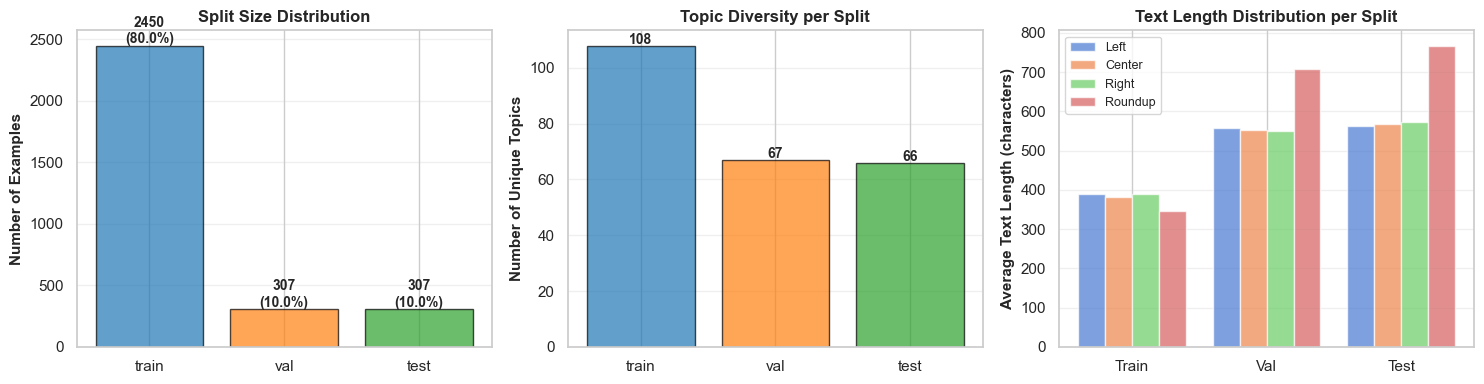

Split analysis plots saved.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Define consistent split order
split_order = ['train', 'val', 'test']
colors_split = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 1. Split size distribution (ensure consistent order)
split_sizes = df[df['split'] != 'unknown']['split'].value_counts()
# Reindex to ensure train, val, test order
split_sizes = split_sizes.reindex(split_order)

axes[0].bar(split_sizes.index, split_sizes.values, color=colors_split, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Examples', fontsize=11, fontweight='bold')
axes[0].set_title('Split Size Distribution', fontsize=12, fontweight='bold')
for i, (split_name, count) in enumerate(split_sizes.items()):
    axes[0].text(i, count + 20, f'{count}\n({count/len(df)*100:.1f}%)', 
                ha='center', fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Topic count per split (use same order)
split_topics = df[df['split'] != 'unknown'].groupby('split')['topic'].nunique()
split_topics = split_topics.reindex(split_order)  # <- KEY FIX

axes[1].bar(split_topics.index, split_topics.values, color=colors_split, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Number of Unique Topics', fontsize=11, fontweight='bold')
axes[1].set_title('Topic Diversity per Split', fontsize=12, fontweight='bold')
for i, (split_name, count) in enumerate(split_topics.items()):
    axes[1].text(i, count + 0.5, str(count), ha='center', fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')



# 3. Length distribution per split
df_splits = df[df['split'] != 'unknown'].copy()
df_splits['left_len'] = df_splits['left_text'].str.len()
df_splits['center_len'] = df_splits['center_text'].str.len()
df_splits['right_len'] = df_splits['right_text'].str.len()
df_splits['roundup_len'] = df_splits['roundup_text'].str.len()

length_data = []
for split_name in ['train', 'val', 'test']:
    split_df = df_splits[df_splits['split'] == split_name]
    avg_left_len = split_df['left_len'].mean()
    avg_center_len = split_df['center_len'].mean()
    avg_right_len = split_df['right_len'].mean()
    avg_roundup_len = split_df['roundup_len'].mean()
    length_data.append([avg_left_len, avg_center_len, avg_right_len, avg_roundup_len])

length_array = np.array(length_data)
x = np.arange(3)
width = 0.2
for i, label in enumerate(['Left', 'Center', 'Right', 'Roundup']):
    axes[2].bar(x + i*width, length_array[:, i], width, label=label, alpha=0.7)
axes[2].set_ylabel('Average Text Length (characters)', fontsize=11, fontweight='bold')
axes[2].set_title('Text Length Distribution per Split', fontsize=12, fontweight='bold')
axes[2].set_xticks(x + 1.5*width)
axes[2].set_xticklabels(['Train', 'Val', 'Test'])
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Split analysis plots saved.")

## 9. Export Processed Data for Next Phase

In [17]:
# Export cleaned dataset for next phase
print("Exporting cleaned dataset...")

# Select important columns
export_cols = [
    'topic', 'issue', 'split',
    'left_text', 'center_text', 'right_text', 'roundup_text',
    'left_title', 'center_title', 'right_title',
    'left_valence', 'left_arousal', 'left_dominance',
    'center_valence', 'center_arousal', 'center_dominance',
    'right_valence', 'right_arousal', 'right_dominance',
    'roundup_valence', 'roundup_arousal', 'roundup_dominance',
    'left_len', 'center_len', 'right_len', 'roundup_len',
    'compression_left', 'compression_center', 'compression_right'
]

df_export = df[export_cols].copy()
export_path = OUTPUT_DIR / 'allsides_processed_with_splits.csv'
df_export.to_csv(export_path, index=False)
print(f"Exported {len(df_export)} records to: {export_path}")

# Also save as pickle for faster loading
import pickle
pickle_path = OUTPUT_DIR / 'allsides_processed_with_splits.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(df_export, f)
print(f"Also saved as pickle: {pickle_path}")

print(f"\n✓ EDA pipeline complete!")
print(f"\nNext steps:")
print(f"1. Review the summary statistics above")
print(f"2. Check visualization files in {OUTPUT_DIR}")
print(f"3. Load processed data for baseline implementation")
print(f"4. Proceed with fine-tuning pipeline")

Exporting cleaned dataset...
Exported 3064 records to: eda_outputs_comprehensive\allsides_processed_with_splits.csv
Also saved as pickle: eda_outputs_comprehensive\allsides_processed_with_splits.pkl

✓ EDA pipeline complete!

Next steps:
1. Review the summary statistics above
2. Check visualization files in eda_outputs_comprehensive
3. Load processed data for baseline implementation
4. Proceed with fine-tuning pipeline
